In [1]:
import numpy as np
import pandas as pd
import cv2

Image data path

In [2]:
dataset_path = "D:\python-venv\multi_channel_NN\data\Houses-dataset\Houses Dataset"

Table data path.

In [3]:
data_table_path = "D:\python-venv\multi_channel_NN\data\Houses-dataset\Houses Dataset\HousesInfo.txt"

Table data havent column name, because of that we are adding manually.

In [4]:
column_name = ['Bedroom','Bathroom','Area','Zipcode','Price']

sep=' ' >>> in the table of information every words seprated by a space.

In [6]:
data_table = pd.read_csv(data_table_path,sep=' ',names=column_name)

Checking for missing values.

In [7]:
data_table.isna().sum()

Bedroom     0
Bathroom    0
Area        0
Zipcode     0
Price       0
dtype: int64

In [8]:
data_table.head()

,Bedroom,Bathroom,Area,Zipcode,Price
0,4,4.0,4053,85255,869500
1,4,3.0,3343,36372,865200
2,3,4.0,3923,85266,889000
3,5,5.0,4022,85262,910000
4,3,4.0,4116,85266,971226


We have to scale the Bedroom , Bathroom , Area data

In [9]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder

In [10]:
scaler = StandardScaler()
encoder = OneHotEncoder()

In [11]:
scaled_table_data = scaler.fit_transform(data_table[['Bedroom','Bathroom','Area']])

In [12]:
scaled_table_data

array([[ 0.53663907,  1.34290707,  1.37982571],
       [ 0.53663907,  0.33701938,  0.79948155],
       [-0.3255288 ,  1.34290707,  1.27356551],
       ...,
       [-0.3255288 , -0.66886831, -0.28682461],
       [ 0.53663907,  0.33701938, -0.04324355],
       [ 1.39880694,  0.33701938,  1.16975747]])

Now we are going to scale the price.
For doing this at first we have to take the max of prices and devide all price data to max

In [13]:
price_max = data_table.Price.max()

In [14]:
Scaled_price = data_table.Price / price_max

Now its time to go encode the Zipcode column
First we have to chek how many types we have in Zipcode column and eleminate that ones with low frecunecy

In [15]:
np.unique(data_table.Zipcode , return_counts=True)

(array([36372, 60002, 60016, 60046, 62025, 62034, 62088, 62214, 62234,
        62249, 81418, 81521, 81524, 85255, 85262, 85266, 85331, 85377,
        90038, 90211, 90265, 90803, 91752, 91901, 91915, 92021, 92040,
        92253, 92276, 92543, 92677, 92692, 92802, 92880, 93105, 93111,
        93314, 93446, 93510, 93720, 93924, 94501, 94531, 94565, 94568,
        95008, 95220, 96019, 98021], dtype=int64),
 array([  1,   3,   2,   1,   2,   1,   1,   4,   7,   1,   2,   1,  11,
         12,   9,  11,   1,   3,   1,   1,   1,   1,   3,  32,   1,  11,
          1,   2, 100,   1,  26,   2,   9,  49,   1,  11,   1,  54,  60,
          1,   1,  41,  22,   1,   1,   1,  10,  12,   4], dtype=int64))

According the top line we have unusefull zipcodes at column Zipcode with frecuency lower than 9

In [16]:
zipcode = np.unique(data_table.Zipcode , return_counts=True)

In [17]:
for i,j in zip(zipcode[0],zipcode[1]):
    if j<9:
        data_table.loc[data_table.Zipcode ==i , 'Zipcode'] = 0

In [18]:
np.unique(data_table.Zipcode , return_counts=True)

(array([    0, 81524, 85255, 85262, 85266, 91901, 92021, 92276, 92677,
        92802, 92880, 93111, 93446, 93510, 94501, 94531, 95220, 96019],
       dtype=int64),
 array([ 55,  11,  12,   9,  11,  32,  11, 100,  26,   9,  49,  11,  54,
         60,  41,  22,  10,  12], dtype=int64))

In [19]:
zipcode_encoded = encoder.fit_transform(data_table.Zipcode.values.reshape(-1,1)).toarray()

In [20]:
data_table.head()

,Bedroom,Bathroom,Area,Zipcode,Price
0,4,4.0,4053,85255,869500
1,4,3.0,3343,0,865200
2,3,4.0,3923,85266,889000
3,5,5.0,4022,85262,910000
4,3,4.0,4116,85266,971226


In [21]:
scaled_table_data.shape

(535, 3)

In [22]:
zipcode_encoded.shape

(535, 18)

In [23]:
Scaled_price.shape

(535,)

In [24]:
cleaned_data_table = np.concatenate([scaled_table_data,zipcode_encoded],axis=1)

In [25]:
cleaned_data_table.shape

(535, 21)

Now its time to preprocessing images

In [26]:
# glob for importing the images
from glob import glob

In [27]:
img_path = glob(dataset_path + "/1_*.jpg")

For sorting in every img_i 4 classes 

In [28]:
img_path.sort()

In [29]:
data_img=[]
for i in range(1,len(data_table)+1):
    img_path = glob(dataset_path + f"/{i}_*.jpg")
    img_list = []
    for path in img_path:
        img = cv2.imread(path)
        img = cv2.resize(img,(64,64))
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img_list.append(img)

    img_combonation = np.zeros([64,64,12])

    img_combonation[:,:,0:3] = img_list[0]
    img_combonation[:,:,3:6] = img_list[1]
    img_combonation[:,:,6:9] = img_list[2]
    img_combonation[:,:,9:12] = img_list[3]

    data_img.append(img_combonation)

data_img = np.array(data_img)/255

In [30]:
X_train_table = cleaned_data_table[:435]
X_test_table = cleaned_data_table[435:]

X_train_img = data_img[:435]
X_test_img = data_img[435:]

y_train_table = Scaled_price[:435]
y_tset_table = Scaled_price[435:]

Now we are going to make our Model

In [32]:
import tensorflow as tf
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPool2D,Input,Dropout,Concatenate
from tensorflow.keras.models import Model

In [33]:
input_layer_Ch1 = Input(shape=(21,) , name='Table_input')
dense_layer1 = Dense(128,activation='relu',name='dense1')(input_layer_Ch1)
dp = Dropout(0.3 , name='dropout1')(dense_layer1)
dense_layer2 = Dense(128,activation='relu' , name='dense2')(dp)

input_layer_Ch2 = Input(shape=(64,64,12) , name='Img_input')
conv_layer1 = Conv2D(16,(3,3) , activation='relu' , name='conv_layer1')(input_layer_Ch2)
maxpool1 = MaxPool2D(name='maxpool1')(conv_layer1)
conv_layer2 = Conv2D(32,(3,3) , name='conv_layer2')(maxpool1)
maxpool2 = MaxPool2D(name='maxpool2')(conv_layer2)
flatten = Flatten(name='fatten')(maxpool2)

concat = Concatenate(name='concat')([dense_layer2 , flatten])

output = Dense(1 , activation='linear' , name='output')(concat)


In [34]:
model = Model(inputs=[input_layer_Ch1 , input_layer_Ch2] , outputs= [output])

In [35]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Img_input           │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_layer1         │ (None, 62, 62,    │      1,744 │ Img_input[0][0]   │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Table_input         │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool1            │ (None, 31, 31,    │          0 │ conv_layer1[0][0] │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 128)       │      2,816 │ Table_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_layer2         │ (None, 29, 29,    │      4,640 │ maxpool1[0][0]    │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 128)       │          0 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool2            │ (None, 14, 14,    │          0 │ conv_layer2[0][0] │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 128)       │     16,512 │ dropout1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fatten (Flatten)    │ (None, 6272)      │          0 │ maxpool2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 6400)      │          0 │ dense2[0][0],     │
│ (Concatenate)       │                   │            │ fatten[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │      6,401 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,113 (125.44 KB)

 Trainable params: 32,113 (125.44 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
from keras.utils import plot_model

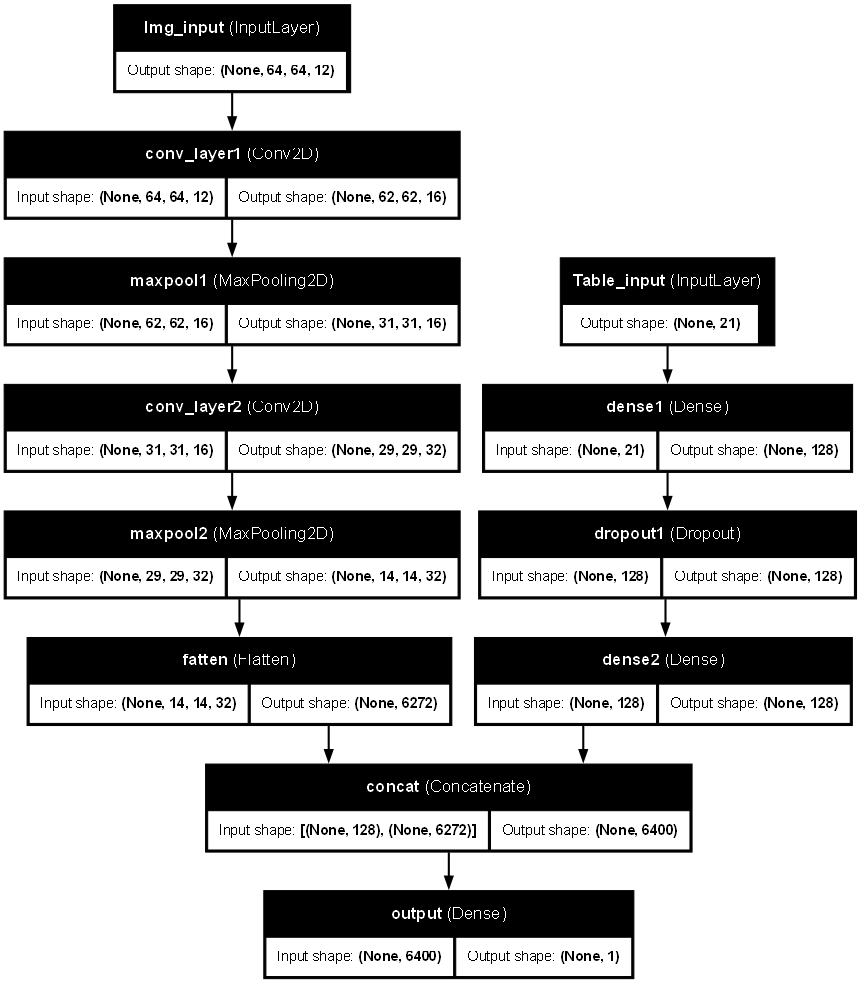

In [37]:
plot_model(model , dpi=75 , show_layer_names=True , show_shapes=True)